# Project 5 – Automation of W-Shaped Tension Member Design (AISC Example D.1)
**Client:** Kiewit Corporation (Internal)  
**Team:** Jacob Kosmicki, Ryder Anderson, Harrison Drake  
**Course:** CIVE 202  
**Date:** April 2026


## Section 1: Package Imports

In [1]:
# install steelpy if not already installed
import sys
!{sys.executable} -m pip install steelpy


   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   -------------------------- ------------- 2/3 [steelp


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Let us import the important packages to be used here.
import matplotlib.pyplot as plt  # plotting library
import numpy as np               # numerical operations
import pandas as pd              # data manipulation and tables
from steelpy import aisc         # AISC steel section property database (new package)

## Section 2: Load and Clean External Data
The steelpy package contains the AISC Shapes Database v15.0. This is an external data source from PyPI (https://pypi.org/project/steelpy/) originally derived from the AISC Steel Construction Manual. We will load the W-shape section properties into a pandas DataFrame, clean it, and use it to pull section properties for our design scenarios instead of hardcoding values.

In [4]:
# Step 1: Load all W-shape sections from steelpy into a pandas DataFrame
# steelpy stores all sections in a dictionary we can iterate through
w_sections = aisc.W_shapes.sections  # get the dictionary of all W shapes

# build a list of rows for our dataframe
rows = []  # empty list to hold each row
for name, section in w_sections.items():  # loop through each section
    props = section.properties  # get the properties dictionary
    props['name'] = name  # add the section name as a column
    rows.append(props)  # add this row to our list

# create the dataframe from the list of dictionaries
w_df = pd.DataFrame(rows)

print(f'Total W-shapes loaded: {len(w_df)}')
print(f'Columns available: {list(w_df.columns)}')
w_df.head()  # show first 5 rows

Total W-shapes loaded: 289
Columns available: ['weight', 'area', 'd', 'bf', 'tw', 'tf', 'k', 'k1', 'Ix', 'Zx', 'Sx', 'rx', 'Iy', 'Zy', 'Sy', 'ry', 'J', 'Cw', 'Wno', 'Sw1', 'Qf', 'Qw', 'rts', 'ho', 'PA', 'PB', 'PC', 'PD', 'T', 'WGi', 'WGo', 'name']


,weight,area,d,bf,tw,tf,k,k1,Ix,Zx,...,rts,ho,PA,PB,PC,PD,T,WGi,WGo,name
0,408.0,120.0,44.8,16.1,1.220,2.17,2.96,1.8125,38700.0,2000.0,...,4.33,42.6,134.0,150.0,106.0,122.0,38.0,5.5,3,W44X408
1,368.0,108.0,44.4,16.0,1.100,1.97,2.76,1.7500,34700.0,1800.0,...,4.28,42.4,133.0,149.0,105.0,121.0,38.0,5.5,3,W44X368
2,335.0,98.5,44.0,15.9,1.030,1.77,2.56,1.7500,31100.0,1620.0,...,4.24,42.2,132.0,148.0,104.0,120.0,38.0,5.5,3,W44X335
3,290.0,85.4,43.6,15.8,0.865,1.58,2.36,1.6250,27000.0,1410.0,...,4.20,42.0,131.0,147.0,103.0,119.0,38.0,5.5,3,W44X290
4,262.0,77.2,43.3,15.8,0.785,1.42,2.20,1.6250,24100.0,1270.0,...,4.17,41.9,131.0,147.0,102.0,118.0,38.0,5.5,3,W44X262


In [5]:
# Step 2: Clean the data - select only the columns we need for tension member design
# rename columns to be more readable
w_clean = w_df[['name', 'weight', 'area', 'd', 'bf', 'tf', 'tw', 'ry']].copy()  # select columns
w_clean.columns = ['Section', 'Weight (lb/ft)', 'Ag (in^2)', 'Depth (in)',
                    'bf (in)', 'tf (in)', 'tw (in)', 'ry (in)']  # rename for clarity

# replace any dash values with NaN
w_clean = w_clean.replace('–', np.nan)  # long dash to NaN
w_clean = w_clean.replace('\u2013', np.nan)  # unicode dash

print(f'Cleaned DataFrame shape: {w_clean.shape}')
print(f'\nData types:\n{w_clean.dtypes}')
print(f'\nMissing values:\n{w_clean.isnull().sum()}')
w_clean.head(10)  # show first 10 rows

Cleaned DataFrame shape: (289, 8)

Data types:
Section            object
Weight (lb/ft)    float64
Ag (in^2)         float64
Depth (in)        float64
bf (in)           float64
tf (in)           float64
tw (in)           float64
ry (in)           float64
dtype: object

Missing values:
Section           0
Weight (lb/ft)    0
Ag (in^2)         0
Depth (in)        0
bf (in)           0
tf (in)           0
tw (in)           0
ry (in)           0
dtype: int64


,Section,Weight (lb/ft),Ag (in^2),Depth (in),bf (in),tf (in),tw (in),ry (in)
0,W44X408,408.0,120.0,44.8,16.1,2.17,1.220,3.56
1,W44X368,368.0,108.0,44.4,16.0,1.97,1.100,3.54
2,W44X335,335.0,98.5,44.0,15.9,1.77,1.030,3.49
3,W44X290,290.0,85.4,43.6,15.8,1.58,0.865,3.49
4,W44X262,262.0,77.2,43.3,15.8,1.42,0.785,3.47
5,W44X230,230.0,67.8,42.9,15.8,1.22,0.710,3.43
6,W40X655,655.0,193.0,43.6,16.9,3.54,1.970,3.86
7,W40X593,593.0,174.0,43.0,16.7,3.23,1.790,3.80
8,W40X503,503.0,148.0,42.1,16.4,2.76,1.540,3.72
9,W40X431,431.0,127.0,41.3,16.2,2.36,1.340,3.65


In [6]:
# Step 3: Load WT-shape sections for centroid distance (x_bar)
wt_sections = aisc.WT_shapes.sections  # get WT shapes dictionary

wt_rows = []  # empty list
for name, section in wt_sections.items():
    props = section.properties
    props['name'] = name
    wt_rows.append(props)

wt_df = pd.DataFrame(wt_rows)

# select only the columns we need
wt_clean = wt_df[['name', 'y']].copy()
wt_clean.columns = ['WT Section', 'x_bar (in)']

print(f'Total WT-shapes loaded: {len(wt_clean)}')
wt_clean.head()

Total WT-shapes loaded: 289


,WT Section,x_bar (in)
0,WT22X204,5.71
1,WT22X184,5.57
2,WT22X167_5,5.53
3,WT22X145,5.26
4,WT22X131,5.19


In [7]:
# Step 4: Create a helper function to pull section properties from the dataframe
# this replaces having to hardcode values from the manual

def get_w_props(section_name):
    """
    Pulls W-shape section properties from the steelpy database.
    
    Input:
        section_name = AISC section name as string (e.g. 'W8X21')
    
    Output:
        dictionary of section properties
    """
    section = aisc.W_shapes.sections[section_name]  # look up the section
    props = section.properties  # get properties
    return props

def get_wt_xbar(wt_name):
    """
    Pulls the centroid distance (y) for a WT-shape from steelpy.
    
    Input:
        wt_name = WT section name as string (e.g. 'WT4X10_5')
    
    Output:
        x_bar = centroid distance in inches
    """
    section = aisc.WT_shapes.sections[wt_name]  # look up the section
    return section.properties['y']  # return the centroid distance

# test it on our Example D.1 section
test = get_w_props('W8X21')
print(f'W8x21 from steelpy: Ag={test["area"]}, bf={test["bf"]}, tf={test["tf"]}, d={test["d"]}, ry={test["ry"]}')

test_xbar = get_wt_xbar('WT4X10_5')
print(f'WT4x10.5 x_bar = {test_xbar} in')

W8x21 from steelpy: Ag=6.16, bf=5.27, tf=0.4, d=8.28, ry=1.26
WT4x10.5 x_bar = 0.831 in


## Section 3: Define Functions for Tension Member Design
These functions automate the AISC Example D.1 W-shaped tension member checks.  
The three checks are: tensile yielding, tensile rupture, and slenderness.

In [8]:
# AISC Design Constants
PHI_YIELDING_LRFD = 0.90       # LRFD resistance factor for yielding
OMEGA_YIELDING_ASD = 1.67      # ASD safety factor for yielding
PHI_RUPTURE_LRFD = 0.75        # LRFD resistance factor for rupture
OMEGA_RUPTURE_ASD = 2.00       # ASD safety factor for rupture
SLENDERNESS_LIMIT = 300        # maximum recommended slenderness ratio L/r

### Step 1: Tensile Yielding Function (AISC Spec Eq. D2-1)

In [9]:
def tensile_yielding(Fy, Ag):
    """
    Checks tensile yielding on the gross section per AISC Spec Eq. D2-1.
    
    Inputs:
        Fy = yield strength (ksi)
        Ag = gross area of the member (in^2)
    
    Outputs:
        Pn = nominal tensile yielding strength (kips)
        LRFD = available strength using phi_t = 0.90 (kips)
        ASD = available strength using omega_t = 1.67 (kips)
    """
    # calculate nominal strength
    Pn = Fy * Ag  # AISC Spec Eq. D2-1
    
    # apply resistance and safety factors
    LRFD = PHI_YIELDING_LRFD * Pn  # LRFD available strength
    ASD = Pn / OMEGA_YIELDING_ASD  # ASD available strength
    
    return Pn, LRFD, ASD

### Step 2: Tensile Rupture Function (AISC Spec Eq. D2-2)

In [10]:
def tensile_rupture(Fu, Ag, num_holes, dh, tf, bf, d, conn_length, x_bar):
    """
    Checks tensile rupture on the net section per AISC Spec Eq. D2-2.
    
    Inputs:
        Fu = ultimate tensile strength (ksi)
        Ag = gross area of the member (in^2)
        num_holes = total number of bolt holes in the cross section
        dh = bolt hole diameter (in)
        tf = flange thickness (in)
        bf = flange width (in)
        d = depth of the W-shape (in)
        conn_length = length of the connection (in)
        x_bar = centroid distance of the WT-shape (in)
    
    Outputs:
        Pn = nominal tensile rupture strength (kips)
        LRFD = available strength using phi_t = 0.75 (kips)
        ASD = available strength using omega_t = 2.00 (kips)
        An = net area (in^2)
        Ae = effective net area (in^2)
        U = shear lag factor used
    """
    # Step 2a: Calculate net area An per AISC Spec Section B4.3b
    An = Ag - num_holes * dh * tf  # net area
    
    # Step 2b: Determine shear lag factor U
    # minimum U for open cross sections
    U_min = (2 * bf * tf) / Ag  # connected flange area / gross area
    
    # Case 2 from AISC Spec Table D3.1
    U_case2 = 1 - (x_bar / conn_length)  # U = 1 - x_bar/l
    
    # Case 7 from AISC Spec Table D3.1
    two_thirds_d = (2 / 3) * d  # 2/3 of the depth
    if bf >= two_thirds_d:  # flange width >= 2/3 depth
        U_case7 = 0.90  # 3 or more fasteners per line
    else:
        U_case7 = 0.85  # 3 or more fasteners per line
    
    # use the largest U value
    U = max(U_min, U_case2, U_case7)
    
    # Step 2c: Calculate effective net area Ae per AISC Spec Eq. D3-1
    Ae = An * U  # effective net area
    
    # Step 2d: Calculate nominal rupture strength per AISC Spec Eq. D2-2
    Pn = Fu * Ae  # nominal tensile rupture strength
    
    # apply resistance and safety factors
    LRFD = PHI_RUPTURE_LRFD * Pn  # LRFD available strength
    ASD = Pn / OMEGA_RUPTURE_ASD  # ASD available strength
    
    return Pn, LRFD, ASD, An, Ae, U

### Step 3: Slenderness Check Function (AISC Spec Section D1)

In [11]:
def slenderness_check(L_ft, ry):
    """
    Checks the recommended slenderness limit per AISC Spec Section D1.
    
    Inputs:
        L_ft = member length (ft)
        ry = least radius of gyration (in)
    
    Outputs:
        ratio = L/r slenderness ratio
        passes = True if L/r <= 300, False if not
    """
    # convert length from feet to inches
    L_in = L_ft * 12  # length in inches
    
    # calculate slenderness ratio
    ratio = L_in / ry  # L/r
    
    # check against limit
    passes = ratio <= SLENDERNESS_LIMIT  # True if ok
    
    return ratio, passes

### Step 4: Main Wrapper Function
This function runs all three checks and determines the governing limit state.

In [12]:
def tension_member_design(name, Fy, Fu, Ag, bf, tf, d, ry, x_bar,
                          num_holes, dh, conn_length, L_ft, DL, LL):
    """
    Complete W-shaped tension member design check per AISC Example D.1.
    
    Inputs:
        name = W-shape designation (string)
        Fy = yield strength (ksi)
        Fu = ultimate tensile strength (ksi)
        Ag = gross area (in^2)
        bf = flange width (in)
        tf = flange thickness (in)
        d = depth (in)
        ry = radius of gyration about y-axis (in)
        x_bar = WT-shape centroid distance (in)
        num_holes = number of bolt holes in cross section
        dh = bolt hole diameter (in)
        conn_length = length of connection (in)
        L_ft = member length (ft)
        DL = dead load (kips)
        LL = live load (kips)
    
    Outputs:
        results = dictionary with all design check results
    """
    # calculate required strength
    Pu = 1.2 * DL + 1.6 * LL  # LRFD required strength
    Pa = DL + LL  # ASD required strength
    
    # run tensile yielding check
    Pn_y, LRFD_y, ASD_y = tensile_yielding(Fy, Ag)
    
    # run tensile rupture check
    Pn_r, LRFD_r, ASD_r, An, Ae, U = tensile_rupture(
        Fu, Ag, num_holes, dh, tf, bf, d, conn_length, x_bar
    )
    
    # run slenderness check
    slender_ratio, slender_ok = slenderness_check(L_ft, ry)
    
    # determine governing limit state (LRFD)
    if LRFD_y <= LRFD_r:
        governing = 'Tensile Yielding'
        LRFD_governing = LRFD_y
        ASD_governing = ASD_y
    else:
        governing = 'Tensile Rupture'
        LRFD_governing = LRFD_r
        ASD_governing = ASD_r
    
    # print results
    print('=' * 55)
    print(f'Tension Member Design: {name}')
    print('=' * 55)
    print(f'Required Strength:  Pu = {Pu:.1f} kips (LRFD)'
          f'  |  Pa = {Pa:.1f} kips (ASD)')
    print('-' * 55)
    print(f'Tensile Yielding:   Pn = {Pn_y:.1f} kips')
    print(f'   LRFD: phi*Pn = {LRFD_y:.1f} kips'
          f'  {"o.k." if LRFD_y >= Pu else "N.G."}')
    print(f'   ASD:  Pn/ohm = {ASD_y:.1f} kips'
          f'  {"o.k." if ASD_y >= Pa else "N.G."}')
    print('-' * 55)
    print(f'Tensile Rupture:    Pn = {Pn_r:.1f} kips')
    print(f'   An = {An:.2f} in^2  |  U = {U:.3f}  |  Ae = {Ae:.2f} in^2')
    print(f'   Ae/Ag = {Ae/Ag:.3f}')
    print(f'   LRFD: phi*Pn = {LRFD_r:.1f} kips'
          f'  {"o.k." if LRFD_r >= Pu else "N.G."}')
    print(f'   ASD:  Pn/ohm = {ASD_r:.1f} kips'
          f'  {"o.k." if ASD_r >= Pa else "N.G."}')
    print('-' * 55)
    print(f'Slenderness:        L/r = {slender_ratio:.1f}'
          f'  {"o.k." if slender_ok else "N.G."} (<= 300)')
    print('-' * 55)
    print(f'Governing Limit State: {governing}')
    print(f'   LRFD Available = {LRFD_governing:.1f} kips'
          f'  vs  Pu = {Pu:.1f} kips')
    print(f'   ASD Available  = {ASD_governing:.1f} kips'
          f'  vs  Pa = {Pa:.1f} kips')
    print('=' * 55)
    print()
    
    # store results in a dictionary for plotting later
    results = {
        'name': name,
        'Pu': Pu,
        'Pa': Pa,
        'LRFD_yielding': LRFD_y,
        'ASD_yielding': ASD_y,
        'LRFD_rupture': LRFD_r,
        'ASD_rupture': ASD_r,
        'slenderness': slender_ratio,
        'governing': governing
    }
    
    return results

## Section 4: Verify Functions Against AISC Example D.1
Run the Example D.1 inputs through our functions to make sure the outputs match the manual.  
Section properties are pulled from steelpy instead of being hardcoded.

In [13]:
# pull W8x21 properties from steelpy database
w8x21 = get_w_props('W8X21')
wt4x10_xbar = get_wt_xbar('WT4X10_5')

# print the properties we pulled to verify
print('Properties pulled from steelpy for W8x21:')
print(f'  Ag = {w8x21["area"]} in^2')
print(f'  bf = {w8x21["bf"]} in')
print(f'  tf = {w8x21["tf"]} in')
print(f'  d  = {w8x21["d"]} in')
print(f'  ry = {w8x21["ry"]} in')
print(f'  WT4x10.5 x_bar = {wt4x10_xbar} in')
print()

# run the verification
verify = tension_member_design(
    name = 'W8x21 (Example D.1 Verification)',
    Fy = 50,                    # ksi, ASTM A992
    Fu = 65,                    # ksi, ASTM A992
    Ag = w8x21['area'],         # from steelpy
    bf = w8x21['bf'],           # from steelpy
    tf = w8x21['tf'],           # from steelpy
    d = w8x21['d'],             # from steelpy
    ry = w8x21['ry'],           # from steelpy
    x_bar = wt4x10_xbar,        # from steelpy
    num_holes = 4,              # 4 bolt holes in cross section
    dh = 0.875,                 # in, 3/4 bolt + 1/8 clearance
    conn_length = 9.0,          # in, 3 bolts at 3 in spacing
    L_ft = 25.0,               # ft, member length
    DL = 30,                    # kips, dead load
    LL = 90                     # kips, live load
)

Properties pulled from steelpy for W8x21:
  Ag = 6.16 in^2
  bf = 5.27 in
  tf = 0.4 in
  d  = 8.28 in
  ry = 1.26 in
  WT4x10.5 x_bar = 0.831 in

Tension Member Design: W8x21 (Example D.1 Verification)
Required Strength:  Pu = 180.0 kips (LRFD)  |  Pa = 120.0 kips (ASD)
-------------------------------------------------------
Tensile Yielding:   Pn = 308.0 kips
   LRFD: phi*Pn = 277.2 kips  o.k.
   ASD:  Pn/ohm = 184.4 kips  o.k.
-------------------------------------------------------
Tensile Rupture:    Pn = 280.8 kips
   An = 4.76 in^2  |  U = 0.908  |  Ae = 4.32 in^2
   Ae/Ag = 0.701
   LRFD: phi*Pn = 210.6 kips  o.k.
   ASD:  Pn/ohm = 140.4 kips  o.k.
-------------------------------------------------------
Slenderness:        L/r = 238.1  o.k. (<= 300)
-------------------------------------------------------
Governing Limit State: Tensile Rupture
   LRFD Available = 210.6 kips  vs  Pu = 180.0 kips
   ASD Available  = 140.4 kips  vs  Pa = 120.0 kips



**Expected results from AISC Example D.1:**  
- Tensile Yielding: phi*Pn = 277 kips (LRFD), Pn/ohm = 184 kips (ASD)  
- Tensile Rupture: phi*Pn = 211 kips (LRFD), Pn/ohm = 141 kips (ASD)  
- Ae/Ag = 0.701  
- U = 0.908  
- L/r = 238  
- Governing: Tensile Rupture

## Section 5: Run Three Design Scenarios
Three different W-shape sections with different connection configurations.  
All section properties are pulled from the steelpy database.

### Scenario 1: W8x21 (Same as Example D.1)

In [14]:
# Scenario 1: W8x21 with original Example D.1 connection
# pull properties from steelpy
s1_props = get_w_props('W8X21')
s1_xbar = get_wt_xbar('WT4X10_5')

s1 = tension_member_design(
    name = 'Scenario 1: W8x21',
    Fy = 50, Fu = 65,
    Ag = s1_props['area'], bf = s1_props['bf'], tf = s1_props['tf'],
    d = s1_props['d'], ry = s1_props['ry'],
    x_bar = s1_xbar,
    num_holes = 4, dh = 0.875,
    conn_length = 9.0, L_ft = 25.0,
    DL = 30, LL = 90
)

Tension Member Design: Scenario 1: W8x21
Required Strength:  Pu = 180.0 kips (LRFD)  |  Pa = 120.0 kips (ASD)
-------------------------------------------------------
Tensile Yielding:   Pn = 308.0 kips
   LRFD: phi*Pn = 277.2 kips  o.k.
   ASD:  Pn/ohm = 184.4 kips  o.k.
-------------------------------------------------------
Tensile Rupture:    Pn = 280.8 kips
   An = 4.76 in^2  |  U = 0.908  |  Ae = 4.32 in^2
   Ae/Ag = 0.701
   LRFD: phi*Pn = 210.6 kips  o.k.
   ASD:  Pn/ohm = 140.4 kips  o.k.
-------------------------------------------------------
Slenderness:        L/r = 238.1  o.k. (<= 300)
-------------------------------------------------------
Governing Limit State: Tensile Rupture
   LRFD Available = 210.6 kips  vs  Pu = 180.0 kips
   ASD Available  = 140.4 kips  vs  Pa = 120.0 kips



### Scenario 2: W10x33 – Larger section, longer connection

In [15]:
# Scenario 2: W10x33 with a longer connection
# pull properties from steelpy
s2_props = get_w_props('W10X33')
s2_xbar = get_wt_xbar('WT5X16_5')

# print to verify what steelpy gives us
print(f'W10x33 from steelpy: Ag={s2_props["area"]}, bf={s2_props["bf"]}, d={s2_props["d"]}, ry={s2_props["ry"]}')
print(f'WT5x16.5 x_bar = {s2_xbar} in')
print()

s2 = tension_member_design(
    name = 'Scenario 2: W10x33',
    Fy = 50, Fu = 65,
    Ag = s2_props['area'], bf = s2_props['bf'], tf = s2_props['tf'],
    d = s2_props['d'], ry = s2_props['ry'],
    x_bar = s2_xbar,
    num_holes = 4, dh = 0.875,
    conn_length = 12.0, L_ft = 30.0,
    DL = 50, LL = 120
)

W10x33 from steelpy: Ag=9.71, bf=7.96, d=9.73, ry=1.94
WT5x16.5 x_bar = 0.869 in

Tension Member Design: Scenario 2: W10x33
Required Strength:  Pu = 252.0 kips (LRFD)  |  Pa = 170.0 kips (ASD)
-------------------------------------------------------
Tensile Yielding:   Pn = 485.5 kips
   LRFD: phi*Pn = 437.0 kips  o.k.
   ASD:  Pn/ohm = 290.7 kips  o.k.
-------------------------------------------------------
Tensile Rupture:    Pn = 493.6 kips
   An = 8.19 in^2  |  U = 0.928  |  Ae = 7.59 in^2
   Ae/Ag = 0.782
   LRFD: phi*Pn = 370.2 kips  o.k.
   ASD:  Pn/ohm = 246.8 kips  o.k.
-------------------------------------------------------
Slenderness:        L/r = 185.6  o.k. (<= 300)
-------------------------------------------------------
Governing Limit State: Tensile Rupture
   LRFD Available = 370.2 kips  vs  Pu = 252.0 kips
   ASD Available  = 246.8 kips  vs  Pa = 170.0 kips



### Scenario 3: W6x15 – Smaller section, shorter connection

In [16]:
# Scenario 3: W6x15 with a shorter connection
# pull properties from steelpy
s3_props = get_w_props('W6X15')
s3_xbar = get_wt_xbar('WT3X7_5')

# print to verify
print(f'W6x15 from steelpy: Ag={s3_props["area"]}, bf={s3_props["bf"]}, d={s3_props["d"]}, ry={s3_props["ry"]}')
print(f'WT3x7.5 x_bar = {s3_xbar} in')
print()

s3 = tension_member_design(
    name = 'Scenario 3: W6x15',
    Fy = 50, Fu = 65,
    Ag = s3_props['area'], bf = s3_props['bf'], tf = s3_props['tf'],
    d = s3_props['d'], ry = s3_props['ry'],
    x_bar = s3_xbar,
    num_holes = 4, dh = 0.875,
    conn_length = 6.0, L_ft = 20.0,
    DL = 20, LL = 50
)

W6x15 from steelpy: Ag=4.43, bf=5.99, d=5.99, ry=1.45
WT3x7.5 x_bar = 0.558 in

Tension Member Design: Scenario 3: W6x15
Required Strength:  Pu = 104.0 kips (LRFD)  |  Pa = 70.0 kips (ASD)
-------------------------------------------------------
Tensile Yielding:   Pn = 221.5 kips
   LRFD: phi*Pn = 199.3 kips  o.k.
   ASD:  Pn/ohm = 132.6 kips  o.k.
-------------------------------------------------------
Tensile Rupture:    Pn = 207.5 kips
   An = 3.52 in^2  |  U = 0.907  |  Ae = 3.19 in^2
   Ae/Ag = 0.721
   LRFD: phi*Pn = 155.6 kips  o.k.
   ASD:  Pn/ohm = 103.8 kips  o.k.
-------------------------------------------------------
Slenderness:        L/r = 165.5  o.k. (<= 300)
-------------------------------------------------------
Governing Limit State: Tensile Rupture
   LRFD Available = 155.6 kips  vs  Pu = 104.0 kips
   ASD Available  = 103.8 kips  vs  Pa = 70.0 kips



### Summary Table of All Scenarios

In [17]:
# create a summary table using pandas
summary = pd.DataFrame([s1, s2, s3])  # create dataframe from results
summary = summary[['name', 'Pu', 'Pa', 'LRFD_yielding', 'LRFD_rupture',
                    'ASD_yielding', 'ASD_rupture', 'slenderness', 'governing']]  # reorder columns
summary.columns = ['Scenario', 'Pu (kips)', 'Pa (kips)', 'LRFD Yield', 'LRFD Rupture',
                    'ASD Yield', 'ASD Rupture', 'L/r', 'Governing']  # rename for readability

# round to 1 decimal place
summary = summary.round(1)

print('=== Summary of All Three Scenarios ===')
summary

=== Summary of All Three Scenarios ===


,Scenario,Pu (kips),Pa (kips),LRFD Yield,LRFD Rupture,ASD Yield,ASD Rupture,L/r,Governing
0,Scenario 1: W8x21,180.0,120,277.2,210.6,184.4,140.4,238.1,Tensile Rupture
1,Scenario 2: W10x33,252.0,170,437.0,370.2,290.7,246.8,185.6,Tensile Rupture
2,Scenario 3: W6x15,104.0,70,199.4,155.6,132.6,103.8,165.5,Tensile Rupture


## Section 6: Plot Scenario Comparison
Compare the LRFD and ASD available strengths for all three scenarios.

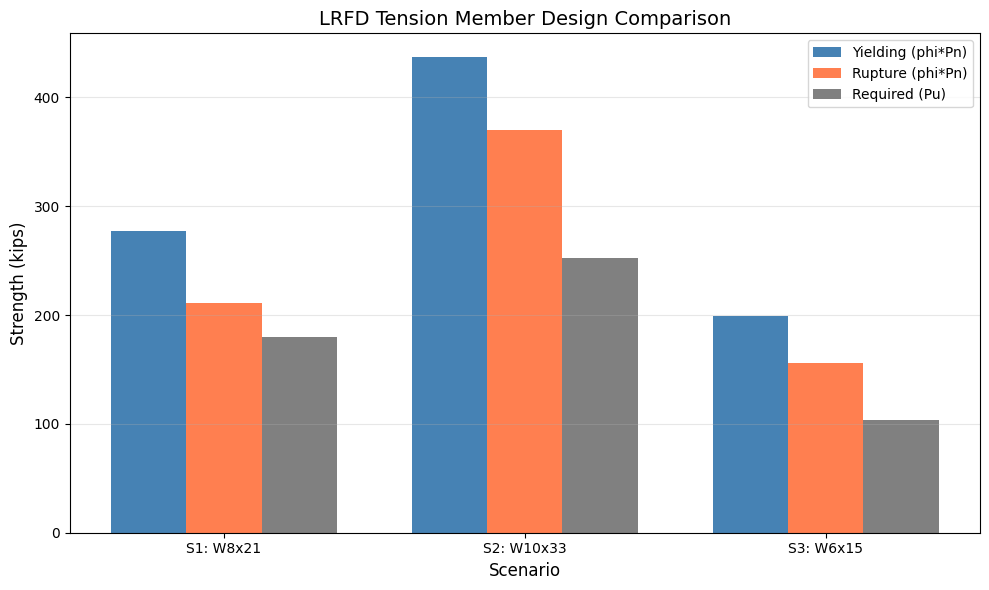

In [18]:
# gather results for plotting
scenarios = [s1, s2, s3]  # list of all scenario results

# extract LRFD values
lrfd_yield = [s['LRFD_yielding'] for s in scenarios]  # LRFD yielding
lrfd_rupt = [s['LRFD_rupture'] for s in scenarios]  # LRFD rupture
required_Pu = [s['Pu'] for s in scenarios]  # required LRFD

# set up the grouped bar chart
x = np.arange(3)  # x positions for each scenario
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(10, 6))  # create figure

# plot bars
ax.bar(x - width, lrfd_yield, width, label='Yielding (phi*Pn)',
       color='steelblue')  # yielding bars
ax.bar(x, lrfd_rupt, width, label='Rupture (phi*Pn)',
       color='coral')  # rupture bars
ax.bar(x + width, required_Pu, width, label='Required (Pu)',
       color='gray')  # required strength bars

# labels and formatting
ax.set_xlabel('Scenario', fontsize=12)
ax.set_ylabel('Strength (kips)', fontsize=12)
ax.set_title('LRFD Tension Member Design Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['S1: W8x21', 'S2: W10x33', 'S3: W6x15'], fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# same plot but for ASD values
asd_yield = [s['ASD_yielding'] for s in scenarios]  # ASD yielding
asd_rupt = [s['ASD_rupture'] for s in scenarios]  # ASD rupture
required_Pa = [s['Pa'] for s in scenarios]  # required ASD

fig, ax = plt.subplots(figsize=(10, 6))  # create figure

ax.bar(x - width, asd_yield, width, label='Yielding (Pn/ohm)',
       color='steelblue')
ax.bar(x, asd_rupt, width, label='Rupture (Pn/ohm)',
       color='coral')
ax.bar(x + width, required_Pa, width, label='Required (Pa)',
       color='gray')

ax.set_xlabel('Scenario', fontsize=12)
ax.set_ylabel('Strength (kips)', fontsize=12)
ax.set_title('ASD Tension Member Design Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['S1: W8x21', 'S2: W10x33', 'S3: W6x15'], fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7: Discussion of Coding Choices

**Why separate functions for each limit state?**  
The yielding, rupture, and slenderness checks were written as individual functions because each check follows a distinct procedure in the AISC specification. Keeping them separate makes it easier for a future Kiewit engineer to update one check without affecting the others. It also makes debugging easier since each function can be tested on its own.

**Why use steelpy instead of hardcoding section properties?**  
The original approach had all section properties typed in by hand from the AISC tables. This is error prone and defeats the purpose of automation. By pulling properties directly from the steelpy database, we eliminate manual lookup errors and make it easy to run the design for any W-shape without editing the code. This is the kind of standardization Kiewit requested.

**Why compute both LRFD and ASD?**  
The AISC manual presents both design methods side by side. Computing both allows the engineer to use whichever method their project requires. This matches the format of Example D.1 in the AISC Design Examples.

**Why these three scenarios?**  
The three scenarios were chosen to show how the governing limit state shifts. Scenario 1 is the baseline from Example D.1 where rupture governs. Scenario 2 uses a larger section with a longer connection to show how increasing the connection length raises U and can shift the governing state. Scenario 3 uses a smaller section with a shorter connection where rupture governs more heavily. This range demonstrates the sensitivity of the design to connection details.

**Bias in the design approach:**  
The automated functions assume standard bolt hole sizes and ASTM A992 steel. If a designer used a different steel grade or non-standard holes, the results would change. The shear lag factor U calculation also depends on the connection geometry which the user must input correctly. The tool automates the math but the engineering judgment on connection layout is still the designer's responsibility.